Load the Dataset

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("heartdata.csv")

# Quick inspection of the data structure
print(df.head())
print(df.info())

   Unnamed: 0     biking    smoking  heartdisease
0           1  30.801246  10.896608     11.769423
1           2  65.129215   2.219563      2.854081
2           3   1.959665  17.588331     17.177803
3           4  44.800196   2.802559      6.816647
4           5  69.428454  15.974505      4.062224
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    498 non-null    int64  
 1   biking        498 non-null    float64
 2   smoking       498 non-null    float64
 3   heartdisease  498 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 15.7 KB
None


Check Assumptions of a Linear Regression Model

Correlation Matrix:
              Unnamed: 0    biking   smoking  heartdisease
Unnamed: 0      1.000000  0.057088  0.052674     -0.051725
biking          0.057088  1.000000  0.015136     -0.935455
smoking         0.052674  0.015136  1.000000      0.309131
heartdisease   -0.051725 -0.935455  0.309131      1.000000


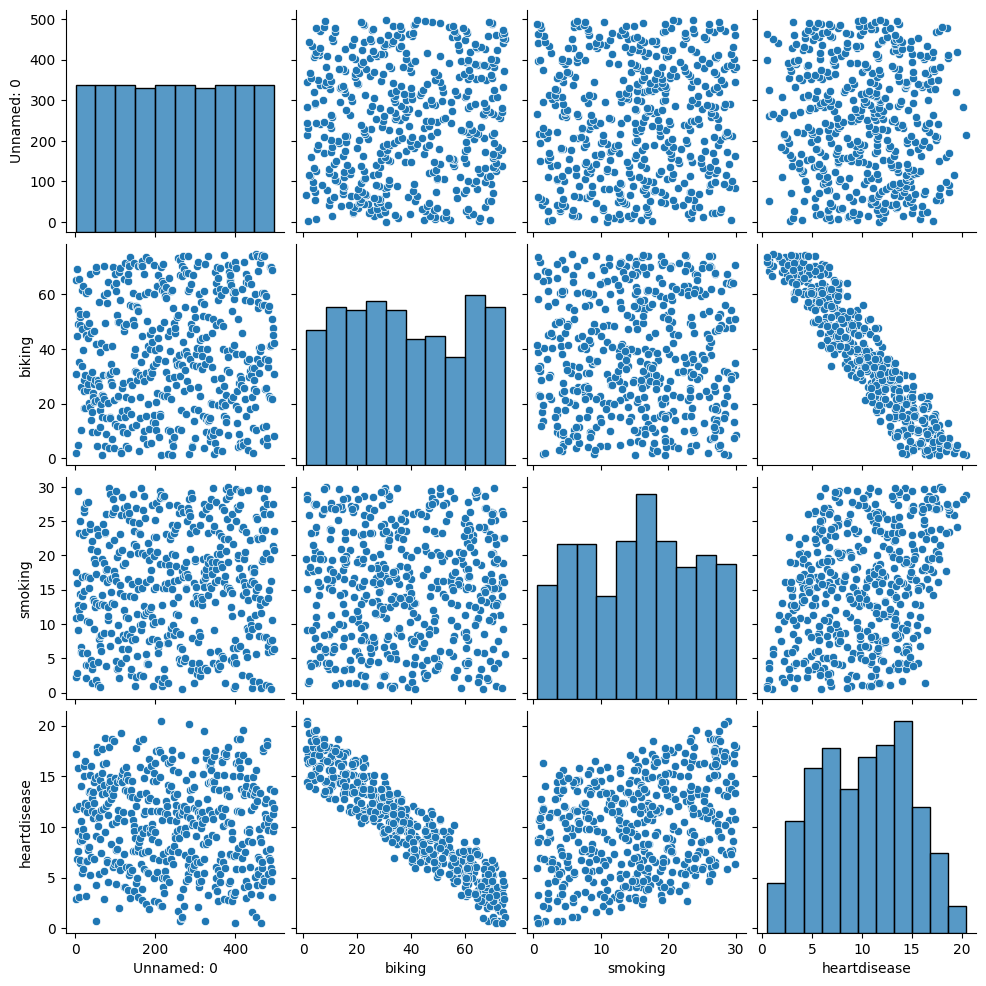

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# 1. Correlation Matrix
print("Correlation Matrix:")
print(df.corr())

# 2. Visualizing Relationships (Pairplot)
sns.pairplot(df)
plt.show()


Fit a Linear Regression Model

In [5]:
from sklearn.linear_model import LinearRegression

# Use the actual column names from heartdata.csv
X = df[['biking', 'smoking']] 
y = df['heartdisease']

# Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

print("Model successfully fitted!")

Model successfully fitted!


Evaluate the Model

Coefficients (Slopes): [-0.20013305  0.17833391]
Intercept: 14.984657987225848
R² Score: 0.9796


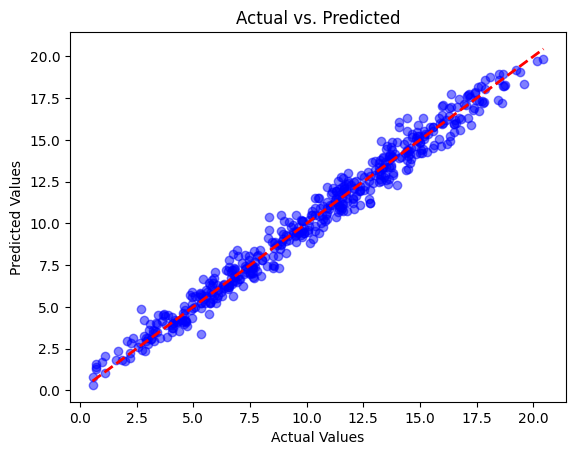

In [6]:
from sklearn.metrics import r2_score

# Extract parameters
print("Coefficients (Slopes):", model.coef_)
print("Intercept:", model.intercept_)

# Generate predictions
predictions = model.predict(X)

# R-squared performance evaluation
r2 = r2_score(y, predictions)
print(f"R² Score: {r2:.4f}")

# Visualize Actual vs. Predicted values
plt.scatter(y, predictions, alpha=0.5, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line of perfect prediction
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted")
plt.show()

Train the Model Using Cross-Validation

In [7]:
from sklearn.model_selection import cross_val_score, train_test_split

# 1. Simple Train-Test Split performance evaluation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=123)
model.fit(X_train, y_train)
test_predictions = model.predict(X_test)
print(f"Test Set R² Score: {r2_score(y_test, test_predictions):.4f}")

# 2. 5-Fold Cross-Validation (returns R² scores by default for linear regression)
cv_scores = cross_val_score(LinearRegression(), X, y, cv=5)
print("Cross-Validation R² scores for each fold:", cv_scores)
print(f"Mean CV R² Score: {cv_scores.mean():.4f}")

Test Set R² Score: 0.9808
Cross-Validation R² scores for each fold: [0.97880962 0.97758166 0.97969241 0.97846831 0.98047549]
Mean CV R² Score: 0.9790
